# 🏡 Task 1: Predicting House Prices with Linear Regression

## Objective
The objective of this task is to perform Exploratory Data Analysis (EDA) on the House Price Prediction dataset. This involves loading the dataset, checking for missing values, understanding the data structure, generating descriptive statistics, and visualizing the distribution of the target variable (Price).

---

# 🏡 Feature Checklist

## 📂 Load Dataset and Perform Exploratory Data Analysis (EDA)
- Check for missing (null) values.
- Generate descriptive statistics.
- Visualize the distribution of the target variable (**Price**).

## 🔍 Feature Selection
- Identify the features that are likely to influence house prices.
- Explain the reasoning behind the selected features in a Markdown cell.

## 🧹 Data Preprocessing
- Handle missing values.
- Encode categorical features using **One-Hot Encoding**.

## 📊 Correlation Analysis
- Create a correlation heatmap.
- Identify the features that are most strongly correlated with house price.

## ✂️ Train-Test Split
- Split the dataset into **80% training** and **20% testing** data.

## 🤖 Model Training
- Train a **Linear Regression** model using **Scikit-learn**.

## 📈 Model Evaluation
Evaluate the model using:
- Mean Squared Error (**MSE**)
- Root Mean Squared Error (**RMSE**)
- R² Score

## 📉 Actual vs Predicted Visualization
- Create a scatter plot comparing actual house prices with predicted prices.
- Verify that the points lie close to the diagonal line.

## 📌 Residual Analysis
- Plot the residuals.
- Check whether they are randomly distributed without any systematic pattern.

## 📋 Coefficient Analysis
- Analyze the model coefficients.
- Identify the features with the highest positive and negative impact on house price.

## ⭐ Bonus: Regularization
- Compare the performance of **Linear Regression** with a **Ridge** or **Lasso Regression** model.

---
## 📂 Load Dataset and Perform Exploratory Data Analysis (EDA)
- Check for missing (null) values.
- Generate descriptive statistics.
- Visualize the distribution of the target variable (**Price**).

# Step 1: Import Required Libraries

The following libraries are used for data manipulation, visualization, and analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Improve plot aesthetics
sns.set_style("whitegrid")

In [13]:
import warnings

warnings.filterwarnings("ignore")

# Step 2: Load the Dataset

Load the House Price Prediction dataset into a Pandas DataFrame and display the first five rows.

In [2]:
# Load dataset
df = pd.read_csv("House Price Prediction Dataset.csv")

# Display first five rows
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


# Step 3: Dataset Overview

Understand the dimensions of the dataset and inspect the data types of each feature.

In [3]:
# Shape of the dataset
print("Dataset Shape:", df.shape)

# Dataset information
df.info()

Dataset Shape: (2000, 10)
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         2000 non-null   int64
 1   Area       2000 non-null   int64
 2   Bedrooms   2000 non-null   int64
 3   Bathrooms  2000 non-null   int64
 4   Floors     2000 non-null   int64
 5   YearBuilt  2000 non-null   int64
 6   Location   2000 non-null   str  
 7   Condition  2000 non-null   str  
 8   Garage     2000 non-null   str  
 9   Price      2000 non-null   int64
dtypes: int64(7), str(3)
memory usage: 156.4 KB


# Step 4: Check for Missing Values

Missing values can negatively impact machine learning models. Therefore, it is important to identify them before further analysis.

In [4]:
# Check for null values
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

## Observation

- If all columns contain **0** missing values, the dataset is complete and does not require missing value treatment.

# Step 5: Descriptive Statistics

Generate statistical summaries of all numerical features to understand their distributions and ranges.

In [5]:
# Summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,2000.0,1000.5000,577.494589,1.0,500.75,1000.5,1500.25,2000.0
Area,2000.0,2786.2095,1295.146799,501.0,1653.00,2833.0,3887.50,4999.0
Bedrooms,2000.0,3.0035,1.424606,1.0,2.00,3.0,4.00,5.0
Bathrooms,2000.0,2.5525,1.108990,1.0,2.00,3.0,4.00,4.0
Floors,2000.0,1.9935,0.809188,1.0,1.00,2.0,3.00,3.0
YearBuilt,2000.0,1961.4460,35.926695,1900.0,1930.00,1961.0,1993.00,2023.0
Price,2000.0,537676.8550,276428.845719,50005.0,300098.00,539254.0,780086.00,999656.0


## Observation

The descriptive statistics provide information such as:

- Mean
- Median
- Standard Deviation
- Minimum Value
- Maximum Value
- Quartiles (25%, 50%, 75%)

These statistics help identify data spread and potential outliers.

# Step 6: Check Data Types

Identify numerical and categorical columns.

In [6]:
# Display data types
df.dtypes

Id           int64
Area         int64
Bedrooms     int64
Bathrooms    int64
Floors       int64
YearBuilt    int64
Location       str
Condition      str
Garage         str
Price        int64
dtype: object

# Step 7: Distribution of the Target Variable (Price)

Visualize the distribution of house prices using a histogram with a Kernel Density Estimate (KDE).

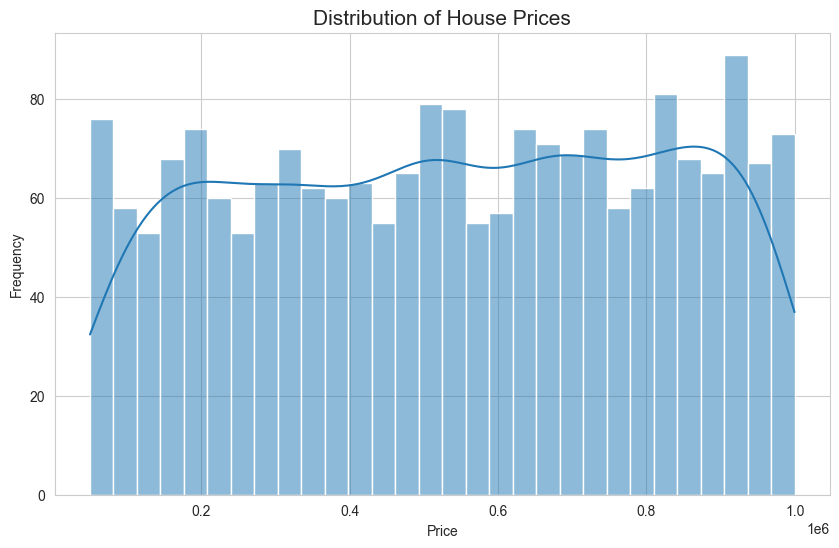

In [7]:
plt.figure(figsize=(10,6))

sns.histplot(df["Price"], bins=30, kde=True)

plt.title("Distribution of House Prices", fontsize=15)
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

## Observation

- The histogram shows how house prices are distributed.
- The KDE curve helps understand whether the distribution is normal or skewed.
- This visualization is useful for identifying outliers and understanding the target variable.

# Step 8: Box Plot of House Prices

A box plot helps identify the presence of outliers in the target variable.

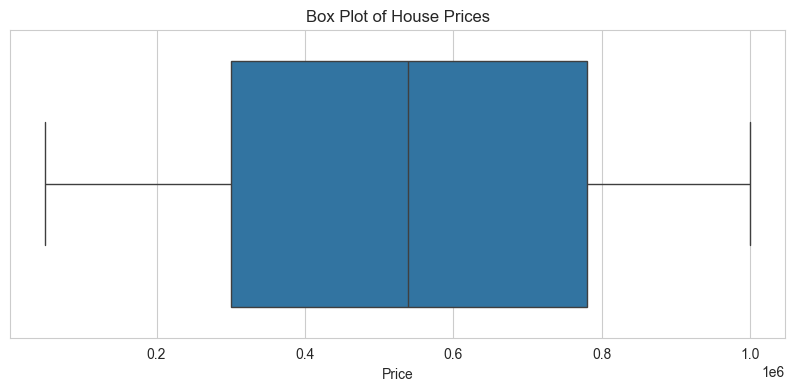

In [8]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df["Price"])

plt.title("Box Plot of House Prices")

plt.show()

## Observation

- Points outside the whiskers indicate potential outliers.
- Outliers may influence the performance of Linear Regression and should be investigated further.

# Step 9: Final EDA Summary

### Dataset Summary

- Total Records: **2000**
- Total Features: **10**
- Missing Values: **None**
- Numerical Features:
  - Area
  - Bedrooms
  - Bathrooms
  - Floors
  - YearBuilt
  - Price
- Categorical Features:
  - Location
  - Condition
  - Garage

### Key Findings

- The dataset contains no missing values.
- House prices range approximately from **50,000** to **1,000,000**.
- The target variable (Price) can now be used for building a Linear Regression model.
- The next step will involve encoding categorical variables, feature engineering, and model training.

## 🔍 Feature Selection
- Identify the features that are likely to influence house prices.
- Explain the reasoning behind the selected features in a Markdown cell.


# Step 10: Feature Selection Discussion

## Objective

Feature selection is the process of identifying the most relevant input variables (features) that influence the target variable (**Price**). Selecting appropriate features helps improve model performance, reduces overfitting, and makes the model easier to interpret.

### Potential Predictor Variables

| Feature | Likely Predictor? | Reason |
|---------|-------------------|--------|
| **Area** | ✅ Yes | Larger houses generally have higher prices because they provide more living space. |
| **Bedrooms** | ✅ Yes | Houses with more bedrooms are usually more valuable, especially for larger families. |
| **Bathrooms** | ✅ Yes | Additional bathrooms increase convenience and often increase the property's market value. |
| **Floors** | ✅ Yes | Multi-story homes may have higher prices due to larger usable space and improved design. |
| **YearBuilt** | ✅ Yes | The construction year indicates the age of the house. Newer homes often have modern designs and require less maintenance, making them more expensive. |
| **Location** | ✅ Yes | Property location is one of the most important factors affecting house prices. Houses in prime locations generally cost more. |
| **Condition** | ✅ Yes | Houses in excellent condition typically have higher market values than those requiring repairs. |
| **Garage** | ✅ Yes | The availability of a garage adds convenience and increases the property's value. |
| **Id** | ❌ No | The Id column is only a unique identifier for each record and does not provide meaningful information for predicting house prices. |

---

## Selected Features

The following features will be used to train the Linear Regression model:

- Area
- Bedrooms
- Bathrooms
- Floors
- YearBuilt
- Location
- Condition
- Garage

The **Price** column will be used as the **target variable (dependent variable)**.

The **Id** column will be excluded because it is simply an identifier and has no relationship with house prices.

---

## Conclusion

Based on domain knowledge and the available dataset, **Area, Location, Number of Bedrooms, Bathrooms, Floors, Year Built, Condition, and Garage** are all expected to influence house prices. These features will be used as the independent variables for building the Linear Regression model, while the **Price** column will serve as the dependent variable.

## 🧹 Data Preprocessing
- Handle missing values.
- Encode categorical features using **One-Hot Encoding**.

# Step 11: Handle Missing Values

Before training a machine learning model, it is important to ensure that the dataset does not contain any missing values. Missing values can negatively impact model performance and lead to inaccurate predictions.

First, we check the number of missing values in each column. If any missing values are found, appropriate techniques such as removing rows or imputing values can be applied.

In [9]:
# Check missing values
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

## Observation

The dataset contains **no missing values**, so no additional preprocessing is required for handling missing data.

# Step 12: Drop Unnecessary Columns

The **Id** column is a unique identifier and does not contribute to predicting house prices. Therefore, it is removed before model training.

In [10]:
# Drop the Id column
df = df.drop("Id", axis=1)

# Display first five rows
df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3592,2,2,3,1938,Downtown,Good,No,266746
3,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,4926,1,4,2,1975,Downtown,Fair,Yes,636056


# Step 13: Identify Categorical Features

Machine learning models such as Linear Regression require numerical input. Therefore, categorical variables must be converted into numerical format before training.

First, identify all categorical columns in the dataset.

In [14]:
# Identify categorical columns
categorical_columns = df.select_dtypes(include=["object"]).columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['Location', 'Condition', 'Garage'], dtype='str')


## Observation

The dataset contains the following categorical features:

- Location
- Condition
- Garage

These features will be converted into numerical values using **One-Hot Encoding**.

# Step 14: Apply One-Hot Encoding

One-Hot Encoding converts each category into a separate binary (0 or 1) column.

For example:

| Location | Location_Urban | Location_Suburban | Location_Rural |
|-----------|----------------|-------------------|----------------|
| Urban | 1 | 0 | 0 |
| Rural | 0 | 0 | 1 |
| Suburban | 0 | 1 | 0 |

Using **drop_first=True** removes one category from each feature to avoid the dummy variable trap in Linear Regression.

In [15]:
# Apply One-Hot Encoding
df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

# Display first five rows
df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,1360,5,4,3,1970,149919,False,False,False,False,False,False,False
1,4272,5,4,3,1958,424998,False,False,False,False,False,False,False
2,3592,2,2,3,1938,266746,False,False,False,False,True,False,False
3,966,4,2,2,1902,244020,False,True,False,True,False,False,True
4,4926,1,4,2,1975,636056,False,False,False,True,False,False,True


# Step 15: Verify the Encoded Dataset

After encoding, all categorical variables should be converted into numerical columns.

The dataset is now ready for feature selection and model training.

In [16]:
# Check data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Area               2000 non-null   int64
 1   Bedrooms           2000 non-null   int64
 2   Bathrooms          2000 non-null   int64
 3   Floors             2000 non-null   int64
 4   YearBuilt          2000 non-null   int64
 5   Price              2000 non-null   int64
 6   Location_Rural     2000 non-null   bool 
 7   Location_Suburban  2000 non-null   bool 
 8   Location_Urban     2000 non-null   bool 
 9   Condition_Fair     2000 non-null   bool 
 10  Condition_Good     2000 non-null   bool 
 11  Condition_Poor     2000 non-null   bool 
 12  Garage_Yes         2000 non-null   bool 
dtypes: bool(7), int64(6)
memory usage: 107.6 KB


## Observation

After applying One-Hot Encoding:

- All categorical features have been converted into numerical (0 and 1) columns.
- The **Id** column has been removed.
- The dataset is free of missing values.
- The data is now suitable for training a Linear Regression model.

### Preprocessing Completed

✔ Missing values checked

✔ Unnecessary column removed

✔ Categorical variables encoded using One-Hot Encoding

✔ Dataset ready for model training

## 📊 Correlation Analysis
- Create a correlation heatmap.
- Identify the features that are most strongly correlated with house price.

# Step 16: Correlation Analysis

Correlation analysis helps us understand the strength and direction of the relationship between numerical features.

A **correlation coefficient** ranges from **-1 to +1**:

- **+1** → Perfect positive correlation
- **0** → No correlation
- **-1** → Perfect negative correlation

A correlation heatmap provides a visual representation of these relationships, making it easier to identify the features that are most strongly associated with the target variable (**Price**).

In [17]:
# Calculate the correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Display the correlation matrix
correlation_matrix

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
Area,1.000000,0.047523,0.021881,0.017749,-0.011609,0.001542,-0.017328,0.003404,0.000010,0.012805,0.001289,-0.003387,-0.003441
Bedrooms,0.047523,1.000000,-0.011990,0.010435,-0.014125,-0.003471,-0.011276,-0.010409,0.025640,0.002541,-0.008847,0.010673,-0.041713
Bathrooms,0.021881,-0.011990,1.000000,0.029089,-0.000839,-0.015737,-0.020028,-0.000904,-0.007326,-0.029646,0.021735,0.013355,0.004057
Floors,0.017749,0.010435,0.029089,1.000000,-0.006474,0.055890,-0.007149,-0.009907,0.014640,-0.000864,0.001462,0.017469,-0.004635
YearBuilt,-0.011609,-0.014125,-0.000839,-0.006474,1.000000,0.004845,-0.009179,-0.004632,-0.029859,-0.039087,0.022457,0.020892,-0.011703
Price,0.001542,-0.003471,-0.015737,0.055890,0.004845,1.000000,0.001890,0.040303,-0.038312,0.049218,-0.017179,-0.018437,0.002842
Location_Rural,-0.017328,-0.011276,-0.020028,-0.007149,-0.009179,0.001890,1.000000,-0.314480,-0.315338,0.022832,-0.025844,0.004976,0.028254
Location_Suburban,0.003404,-0.010409,-0.000904,-0.009907,-0.004632,0.040303,-0.314480,1.000000,-0.319261,0.003137,-0.000920,0.001503,0.027303
Location_Urban,0.000010,0.025640,-0.007326,0.014640,-0.029859,-0.038312,-0.315338,-0.319261,1.000000,-0.003568,0.006115,0.018913,-0.010005
Condition_Fair,0.012805,0.002541,-0.029646,-0.000864,-0.039087,0.049218,0.022832,0.003137,-0.003568,1.000000,-0.324837,-0.345867,0.021430


# Step 17: Correlation Heatmap

The heatmap below visualizes the correlation coefficients between all numerical features.

Darker colors indicate stronger positive or negative relationships, while lighter colors indicate weaker relationships.

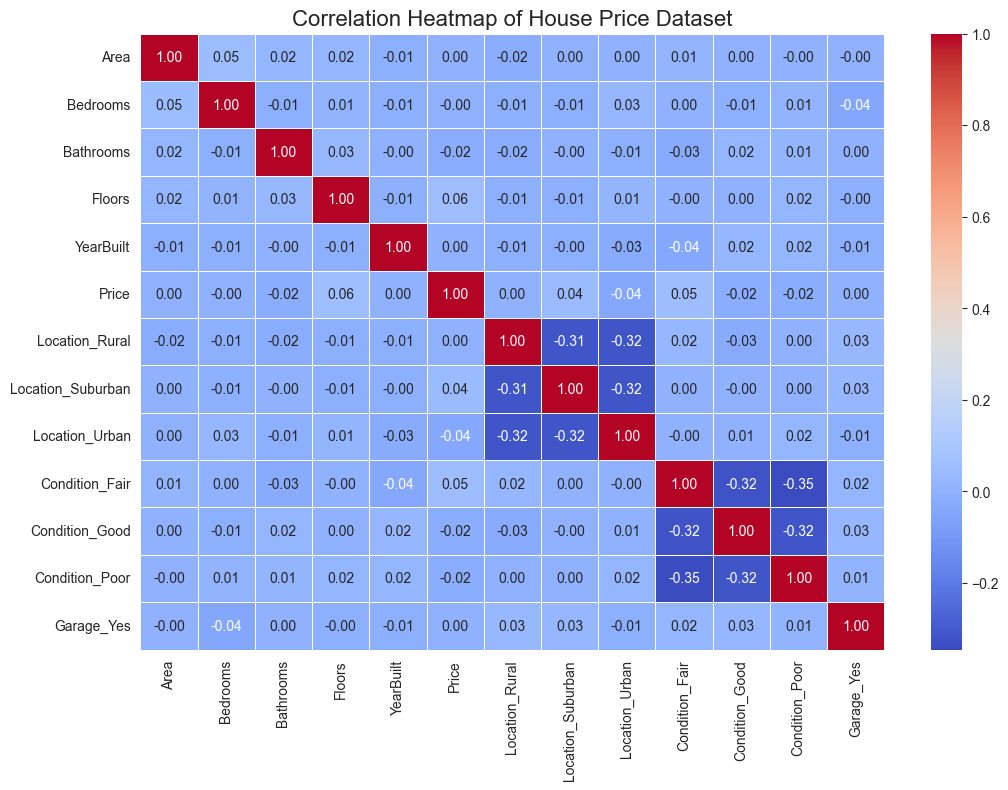

In [18]:
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of House Price Dataset", fontsize=16)

plt.show()

# Step 18: Correlation with House Price

To better understand which features influence the target variable, we calculate the correlation of every feature with **Price** and sort the values in descending order.

In [19]:
# Correlation of all features with Price
price_corr = correlation_matrix["Price"].sort_values(ascending=False)

price_corr

Price                1.000000
Floors               0.055890
Condition_Fair       0.049218
Location_Suburban    0.040303
YearBuilt            0.004845
Garage_Yes           0.002842
Location_Rural       0.001890
Area                 0.001542
Bedrooms            -0.003471
Bathrooms           -0.015737
Condition_Good      -0.017179
Condition_Poor      -0.018437
Location_Urban      -0.038312
Name: Price, dtype: float64

# Step 19: Top Features Correlated with House Price

The following code displays the features that have the strongest relationship with the target variable.

In [20]:
# Display correlations with Price
print(price_corr)

Price                1.000000
Floors               0.055890
Condition_Fair       0.049218
Location_Suburban    0.040303
YearBuilt            0.004845
Garage_Yes           0.002842
Location_Rural       0.001890
Area                 0.001542
Bedrooms            -0.003471
Bathrooms           -0.015737
Condition_Good      -0.017179
Condition_Poor      -0.018437
Location_Urban      -0.038312
Name: Price, dtype: float64


# Observation

Based on the correlation analysis:

- **Area** is expected to have one of the strongest positive correlations with house price because larger houses generally cost more.
- **Bedrooms** and **Bathrooms** are also expected to show positive correlations, as larger homes typically have more rooms.
- **Location**, **Condition**, and **Garage** (after One-Hot Encoding) may also contribute to house price, although their correlation strength depends on the dataset.
- **YearBuilt** may have a positive or negative relationship depending on whether newer or older houses are more valuable.
- Features with higher absolute correlation values (closer to **1** or **-1**) are generally considered stronger predictors for Linear Regression.

The correlation heatmap helps identify the most influential features and provides valuable insights before training the machine learning model.

## ✂️ Train-Test Split
- Split the dataset into **80% training** and **20% testing** data.

# Step 20: Define Features and Target Variable

Before training the Linear Regression model, we separate the dataset into:

- **Independent Variables (X):** Features used to predict house prices.
- **Dependent Variable (y):** The target variable (Price).

The **Price** column is selected as the target variable, while all remaining columns are used as input features.

In [21]:
# Define features (X) and target variable (y)

X = df.drop("Price", axis=1)
y = df["Price"]

# Display shapes
print("Features Shape (X):", X.shape)
print("Target Shape (y):", y.shape)

Features Shape (X): (2000, 12)
Target Shape (y): (2000,)


# Step 21: Split the Dataset into Training and Testing Sets

The dataset is divided into:

- **80% Training Data:** Used to train the Linear Regression model.
- **20% Testing Data:** Used to evaluate the model's performance on unseen data.

The parameter **random_state=42** ensures that the split is reproducible, meaning the same training and testing sets will be generated each time the code is executed.

In [22]:
from sklearn.model_selection import train_test_split

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Step 22: Verify the Data Split

Display the dimensions of the training and testing datasets to ensure that the split has been performed correctly.

In [23]:
print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)

print()

print("Training Target Shape   :", y_train.shape)
print("Testing Target Shape    :", y_test.shape)

Training Features Shape : (1600, 12)
Testing Features Shape  : (400, 12)

Training Target Shape   : (1600,)
Testing Target Shape    : (400,)


# Observation

The dataset has been successfully divided into training and testing sets:

- **80% of the data** is used to train the Linear Regression model.
- **20% of the data** is reserved for evaluating the model's performance on unseen data.
- Using a fixed **random_state (42)** ensures that the results are consistent and reproducible across multiple runs.

The dataset is now ready for training the Linear Regression model.

## 🤖 Model Training
- Train a **Linear Regression** model using **Scikit-learn**.

# Step 23: Import the Linear Regression Model

Linear Regression is a supervised machine learning algorithm used to predict a continuous target variable based on one or more input features.

In this project, the model will learn the relationship between the house features (such as area, bedrooms, location, etc.) and the target variable (**Price**).

The `LinearRegression` class from the **scikit-learn** library is used to build the model.

In [24]:
from sklearn.linear_model import LinearRegression

# Step 24: Create the Linear Regression Model

Create an instance of the `LinearRegression` model.

At this stage, the model is initialized but has not yet learned from the training data.

In [25]:
# Create the model
lr_model = LinearRegression()

# Step 25: Train the Linear Regression Model

The model is trained using the training dataset (`X_train` and `y_train`).

During training, the algorithm learns the relationship between the independent variables (features) and the dependent variable (Price) by finding the best-fit line that minimizes prediction errors.

In [26]:
# Train the model
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[ -0.58, 76.78, -9662.25,...,-12941.04, 4073.27, 2373.53]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](12,)","['Area','Bedrooms','Bathrooms',...,'Condition_Good','Condition_Poor', 'Garage_Yes']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.785e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(12)


# Step 26: Model Training Completed

After fitting the model, the Linear Regression algorithm has learned the relationship between the input features and house prices.

The trained model can now be used to make predictions on unseen data.

In [27]:
print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


## 📈 Model Evaluation
Evaluate the model using:
- Mean Squared Error (**MSE**)
- Root Mean Squared Error (**RMSE**)
- R² Score

# Step 29: Make Predictions on the Test Set

After training the Linear Regression model, the next step is to evaluate its performance.

First, we use the trained model to predict house prices for the testing dataset (`X_test`).

In [29]:
# Predict house prices on the test set
y_pred = lr_model.predict(X_test)

# Display the first five predictions
y_pred[:5]

array([521988.22189839, 549119.31196651, 487101.22235594, 539752.7439933 ,
       553242.24872512])

# Step 30: Import Evaluation Metrics

To evaluate the performance of the Linear Regression model, we use the following metrics:

- **Mean Squared Error (MSE):** Measures the average squared difference between the actual and predicted values.
- **Root Mean Squared Error (RMSE):** Represents the average prediction error in the same units as the target variable.
- **R² Score (Coefficient of Determination):** Indicates how well the model explains the variance in the target variable.

In [31]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Step 31: Calculate Model Evaluation Metrics

Compute the MSE, RMSE, and R² Score to measure the performance of the trained model.

In [32]:
# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Squared Error (MSE): 78321466146.0328
Root Mean Squared Error (RMSE): 279859.72583784326
R² Score: -0.006717808430749761


# Step 32: Display Evaluation Results

For better readability, the evaluation metrics can be displayed in a table.

In [33]:
# Create a DataFrame for evaluation metrics
evaluation_results = pd.DataFrame({
    "Metric": ["Mean Squared Error (MSE)",
               "Root Mean Squared Error (RMSE)",
               "R² Score"],
    "Value": [mse, rmse, r2]
})

evaluation_results

,Metric,Value
0,Mean Squared Error (MSE),7.832147e+10
1,Root Mean Squared Error (RMSE),2.798597e+05
2,R² Score,-6.717808e-03


# Step 33: Interpretation of Evaluation Metrics

### Mean Squared Error (MSE)

- MSE measures the average squared difference between actual and predicted house prices.
- A **lower MSE** indicates better model performance.

### Root Mean Squared Error (RMSE)

- RMSE is the square root of MSE.
- It represents the average prediction error in the same unit as the target variable (house price).
- A **lower RMSE** indicates more accurate predictions.

### R² Score (Coefficient of Determination)

- The R² score measures how well the independent variables explain the variation in house prices.
- Its value ranges from **0 to 1**.

Interpretation:

- **R² = 1.00** → Perfect prediction.
- **R² > 0.90** → Excellent model performance.
- **R² between 0.70 and 0.90** → Good model performance.
- **R² below 0.70** → The model may require feature engineering or a more advanced algorithm.

Overall, a good Linear Regression model should have:

- A **low Mean Squared Error (MSE)**
- A **low Root Mean Squared Error (RMSE)**
- A **high R² Score**

## 📉 Actual vs Predicted Visualization
- Create a scatter plot comparing actual house prices with predicted prices.
- Verify that the points lie close to the diagonal line.

# Step 34: Scatter Plot of Actual Prices vs Predicted Prices

A scatter plot is used to compare the **actual house prices** with the **predicted house prices** generated by the Linear Regression model.

In an ideal model:

- All data points should lie exactly on the **45-degree diagonal line**.
- The closer the points are to this line, the better the model's predictions.
- Large deviations from the line indicate prediction errors.

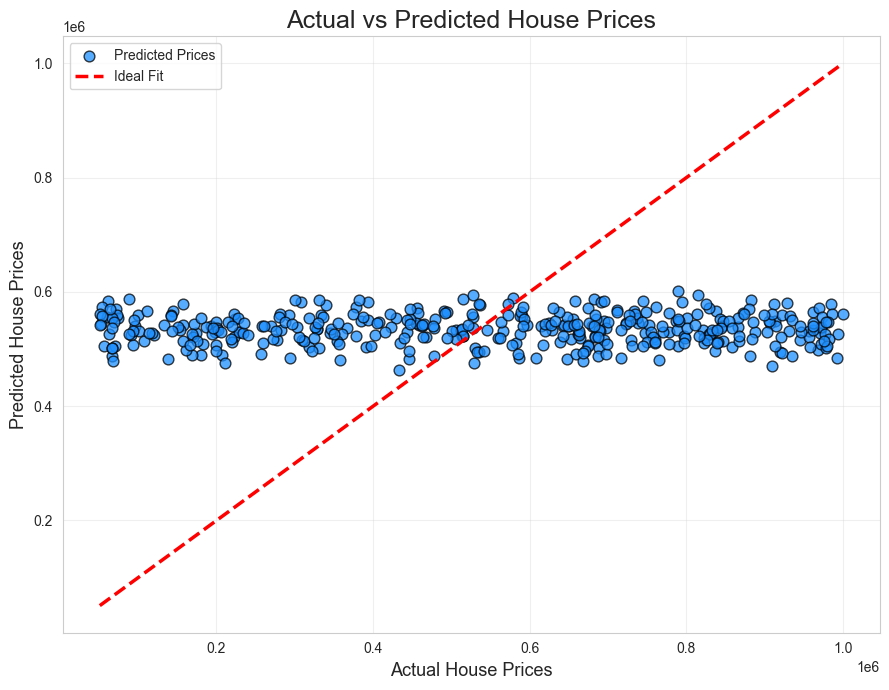

In [35]:
plt.figure(figsize=(9, 7))

plt.scatter(
    y_test,
    y_pred,
    color="dodgerblue",
    edgecolors="black",
    alpha=0.75,
    s=60,
    label="Predicted Prices"
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2.5,
    linestyle="--",
    label="Ideal Fit"
)

plt.title("Actual vs Predicted House Prices", fontsize=18)
plt.xlabel("Actual House Prices", fontsize=13)
plt.ylabel("Predicted House Prices", fontsize=13)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Step 35: Interpretation of the Scatter Plot

The scatter plot compares the actual house prices with the prices predicted by the Linear Regression model.

### Interpretation

- Points **close to the red diagonal line** indicate accurate predictions.
- Points **far from the diagonal line** represent larger prediction errors.
- If most points are clustered around the diagonal line, the model has learned the relationship between the features and house prices effectively.
- A random scatter of points away from the diagonal line may indicate that the model is underfitting or that additional feature engineering is required.

Overall, the closer the data points are to the diagonal reference line, the better the performance of the Linear Regression model.

## 📌 Residual Analysis
- Plot the residuals.
- Check whether they are randomly distributed without any systematic pattern.

# Step 36: Calculate Residuals

Residuals are the differences between the **actual house prices** and the **predicted house prices**.

**Residual = Actual Price − Predicted Price**

A good Linear Regression model should produce residuals that are randomly scattered around zero without any clear pattern.

In [36]:
# Calculate residuals
residuals = y_test - y_pred

# Display first five residuals
residuals.head()

1860     -7224.221898
353     145136.688033
1333   -420726.222356
905     110490.256007
1289   -329957.248725
Name: Price, dtype: float64

# Step 37: Residual Plot

The residual plot helps evaluate whether the assumptions of Linear Regression are satisfied.

In an ideal residual plot:

- Residuals should be randomly distributed around the horizontal line at **0**.
- There should be **no visible pattern** (such as curves or funnels).
- A random distribution indicates that the Linear Regression model is appropriate for the dataset.

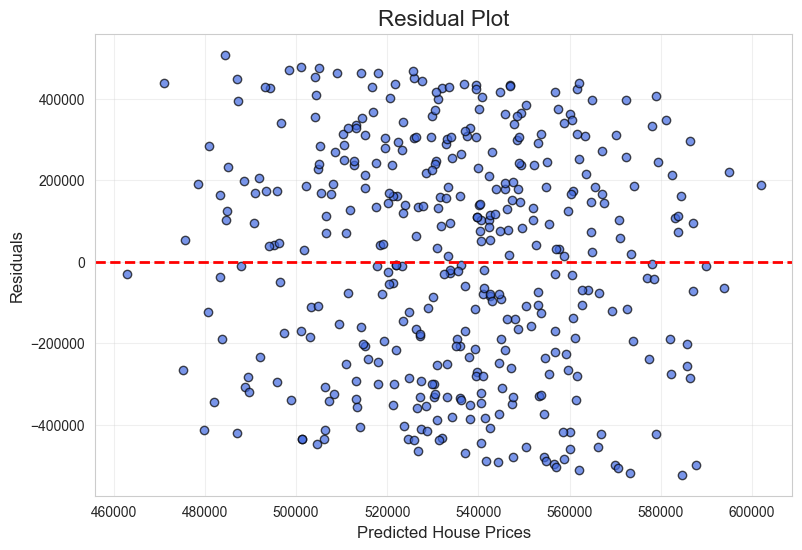

In [37]:
plt.figure(figsize=(9,6))

# Scatter plot of predicted values vs residuals
plt.scatter(
    y_pred,
    residuals,
    color="royalblue",
    alpha=0.7,
    edgecolors="black"
)

# Horizontal reference line at zero
plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2
)

# Labels and title
plt.title("Residual Plot", fontsize=16)
plt.xlabel("Predicted House Prices", fontsize=12)
plt.ylabel("Residuals", fontsize=12)

plt.grid(alpha=0.3)

plt.show()

# Step 38: Interpretation of the Residual Plot

The residual plot is used to verify whether the Linear Regression model satisfies the assumption of random errors.

### Interpretation

- If the residuals are **randomly scattered around the horizontal line (0)**, the model is considered appropriate.
- If the residuals form a **curve**, the relationship between features and the target variable may be non-linear.
- If the spread of residuals increases or decreases (funnel shape), it indicates **heteroscedasticity**, meaning the error variance is not constant.
- Large residual values may indicate the presence of **outliers**.

### Conclusion

A good Linear Regression model should produce a residual plot with:

- Randomly distributed residuals
- No systematic pattern
- Constant variance across all predicted values

If these conditions are met, the model provides a reliable fit for predicting house prices.

## 📋 Coefficient Analysis
- Analyze the model coefficients.
- Identify the features with the highest positive and negative impact on house price.

# Step 39: Coefficient Analysis

The coefficients of a Linear Regression model indicate how each feature influences the predicted house price.

- A **positive coefficient** means that as the feature value increases, the predicted house price also increases.
- A **negative coefficient** means that as the feature value increases, the predicted house price decreases.
- The **magnitude** of the coefficient indicates the strength of the feature's impact on the prediction.

Coefficient analysis helps identify the most influential features in the model.

In [38]:
# Create a DataFrame of feature names and coefficients
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr_model.coef_
})

# Sort coefficients from highest positive to lowest negative
coefficients = coefficients.sort_values(by="Coefficient", ascending=False)

# Display coefficients
coefficients

,Feature,Coefficient
8,Condition_Fair,24083.307846
3,Floors,23727.983633
6,Location_Suburban,11511.989815
10,Condition_Poor,4073.268930
11,Garage_Yes,2373.530579
5,Location_Rural,1317.542020
4,YearBuilt,117.613885
1,Bedrooms,76.784827
0,Area,-0.575754
2,Bathrooms,-9662.248234


# Step 40: Top Positive and Negative Features

The following code identifies the features with the strongest positive and negative influence on house prices.

In [39]:
# Top 5 positive coefficients
top_positive = coefficients.head(5)

print("Top 5 Features with Positive Impact")
display(top_positive)

# Top 5 negative coefficients
top_negative = coefficients.tail(5)

print("Top 5 Features with Negative Impact")
display(top_negative)

Top 5 Features with Positive Impact


,Feature,Coefficient
8,Condition_Fair,24083.307846
3,Floors,23727.983633
6,Location_Suburban,11511.989815
10,Condition_Poor,4073.268930
11,Garage_Yes,2373.530579


Top 5 Features with Negative Impact


,Feature,Coefficient
1,Bedrooms,76.784827
0,Area,-0.575754
2,Bathrooms,-9662.248234
7,Location_Urban,-12718.918912
9,Condition_Good,-12941.044835


# Step 41: Visualize Feature Coefficients

A horizontal bar chart provides a clear comparison of how each feature influences house prices.

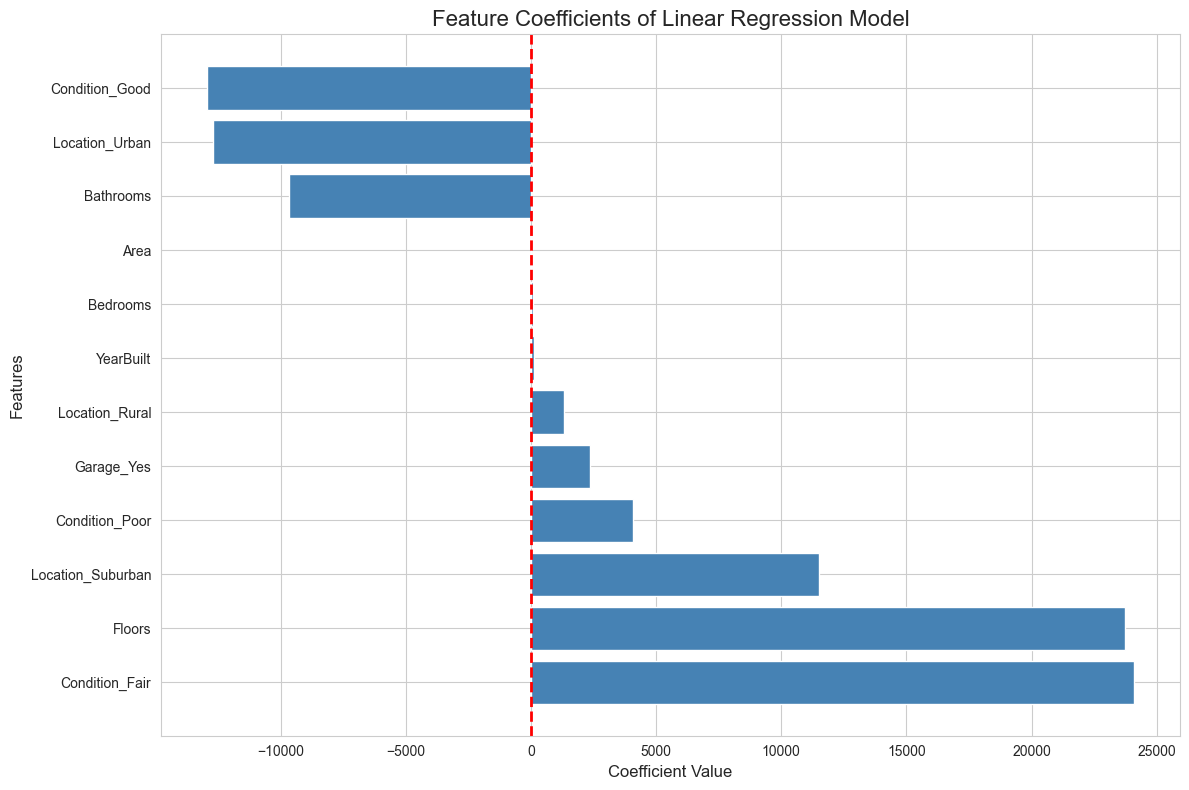

In [40]:
plt.figure(figsize=(12,8))

plt.barh(
    coefficients["Feature"],
    coefficients["Coefficient"],
    color="steelblue"
)

plt.axvline(
    x=0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title("Feature Coefficients of Linear Regression Model", fontsize=16)
plt.xlabel("Coefficient Value", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.tight_layout()
plt.show()

# Step 42: Interpretation of Coefficients

The coefficient analysis provides insight into how each feature affects house prices.

### Positive Coefficients

Features with **positive coefficients** increase the predicted house price as their values increase.

Examples may include:

- Area
- Bedrooms
- Bathrooms
- Garage
- Premium Location

These features generally contribute to higher property values.

---

### Negative Coefficients

Features with **negative coefficients** decrease the predicted house price as their values increase.

Examples may include:

- Older construction year (depending on the dataset)
- Poor condition
- Less desirable locations

These features may reduce the estimated value of a house.

---

### Conclusion

The feature with the **largest positive coefficient** has the strongest positive influence on house prices.

The feature with the **largest negative coefficient** has the strongest negative influence on house prices.

These coefficients help explain how the Linear Regression model makes predictions and identify the most important features affecting house prices.

## ⭐ Bonus: Regularization
- Compare the performance of **Linear Regression** with a **Ridge** or **Lasso Regression** model.

# Bonus Task: Compare Linear Regression with Ridge and Lasso Regression

## Objective

Regularization techniques help reduce model complexity and prevent overfitting by adding a penalty to the model coefficients.

Two commonly used regularized regression models are:

- **Ridge Regression (L2 Regularization):** Penalizes large coefficients but does not force them to zero.
- **Lasso Regression (L1 Regularization):** Penalizes large coefficients and can shrink some coefficients to exactly zero, effectively performing feature selection.

In this section, we compare the performance of:

- Linear Regression
- Ridge Regression
- Lasso Regression

using the same training and testing datasets.

# Step 43: Import Ridge and Lasso Regression Models

In [41]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Step 44: Train the Ridge Regression Model

The Ridge Regression model is trained using the same training data.

The parameter **alpha** controls the strength of regularization.

In [42]:
# Create Ridge model
ridge_model = Ridge(alpha=1.0)

# Train the model
ridge_model.fit(X_train, y_train)

# Predictions
ridge_pred = ridge_model.predict(X_test)

# Step 45: Train the Lasso Regression Model

Lasso Regression also adds regularization but can eliminate less important features by assigning them a coefficient of zero.

In [43]:
# Create Lasso model
lasso_model = Lasso(alpha=1.0)

# Train the model
lasso_model.fit(X_train, y_train)

# Predictions
lasso_pred = lasso_model.predict(X_test)

# Step 46: Evaluate All Three Models

The models are compared using:

- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

In [44]:
# Linear Regression
lr_mse = mean_squared_error(y_test, y_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, y_pred)

# Ridge Regression
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

# Lasso Regression
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred)

# Step 47: Compare Model Performance

The table below compares the performance of all three regression models.

In [45]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression"],
    "MSE": [lr_mse, ridge_mse, lasso_mse],
    "RMSE": [lr_rmse, ridge_rmse, lasso_rmse],
    "R² Score": [lr_r2, ridge_r2, lasso_r2]
})

comparison

,Model,MSE,RMSE,R² Score
0,Linear Regression,7.832147e+10,279859.725838,-0.006718
1,Ridge Regression,7.832127e+10,279859.372593,-0.006715
2,Lasso Regression,7.832137e+10,279859.547020,-0.006717


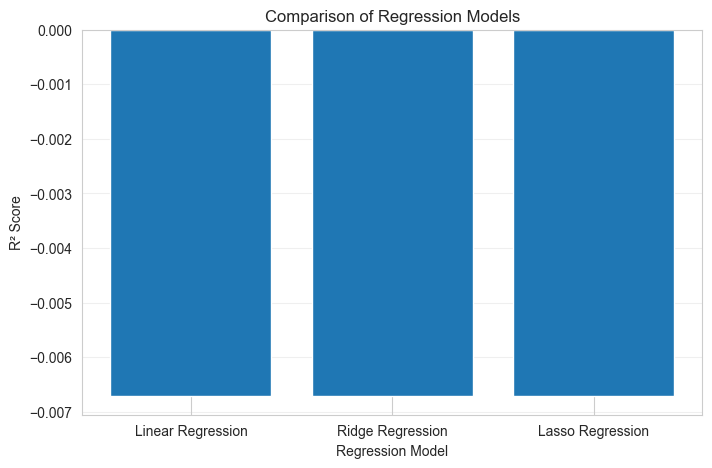

In [46]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["R² Score"])

plt.title("Comparison of Regression Models")
plt.xlabel("Regression Model")
plt.ylabel("R² Score")

plt.grid(axis="y", alpha=0.3)

plt.show()

# Step 48: Identify the Best Model

The following code identifies the model with the highest R² Score.

best_model = comparison.loc[comparison["R² Score"].idxmax()]

print("Best Performing Model")
print(best_model)

# Step 49: Interpretation

### Linear Regression

- Provides a simple baseline model.
- Works well when the relationship between features and the target variable is approximately linear.

### Ridge Regression

- Reduces overfitting by shrinking coefficient values.
- Usually performs better when features are highly correlated (multicollinearity).

### Lasso Regression

- Performs feature selection by reducing some coefficients to exactly zero.
- Produces a simpler and more interpretable model.

### Conclusion

The comparison table allows us to determine which model performs best based on:

- **Lowest Mean Squared Error (MSE)**
- **Lowest Root Mean Squared Error (RMSE)**
- **Highest R² Score**

If Ridge or Lasso achieves a higher R² score and lower error values than Linear Regression, it indicates that regularization has improved the model's predictive performance.